In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv(r"C:\Users\my\Desktop\Student_Performance.csv")

In [5]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [7]:
df.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [8]:
df = df.drop("student_id",axis=1)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'gender',
    'school_type',
    'parent_education',
    'internet_access',
    'extra_activities',
    'study_method',
    'final_grade'
]

for col in categorical_cols:
    df[col] = df[col].astype(str)   # convert to string
    df[col] = le.fit_transform(df[col])

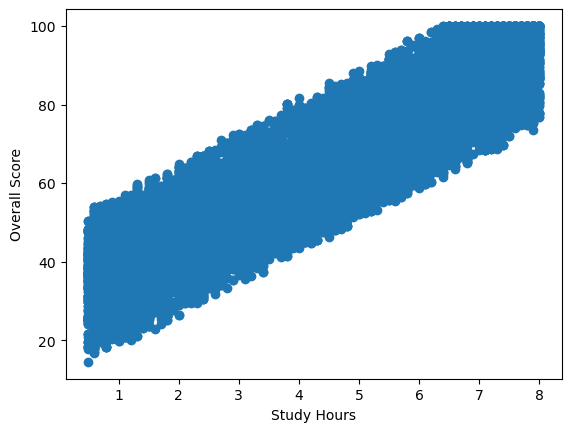

In [14]:
plt.scatter(df["study_hours"],df["overall_score"])
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.show()

In [15]:
X = df.drop("overall_score",axis=1)

In [16]:
Y = df["overall_score"]

In [17]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [20]:
df.dtypes

age                        int64
gender                     int64
school_type                int64
parent_education           int64
study_hours              float64
attendance_percentage    float64
internet_access            int64
travel_time               object
extra_activities           int64
study_method               int64
math_score               float64
science_score            float64
english_score            float64
overall_score            float64
final_grade                int64
dtype: object

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
X = df.drop("overall_score",axis=1)
Y = df["overall_score"]

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,Y_train)

LinearRegression()

In [25]:
Y_pred = model.predict(X_test)

In [26]:
print("R2 Score:",r2_score(Y_test,Y_pred))

R2 Score: 0.9748753816571495


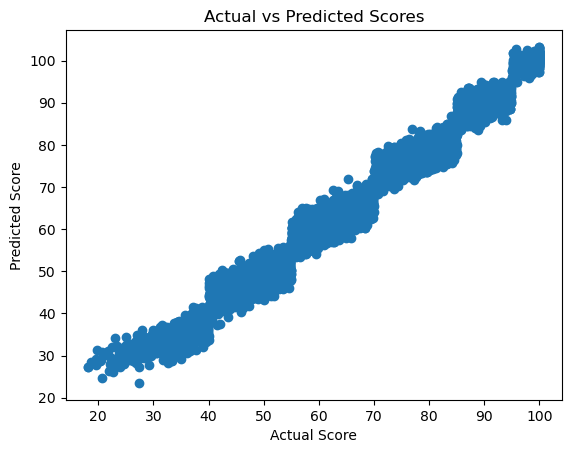

In [27]:
plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()

In [29]:
X = df.drop("overall_score",axis=1)
Y = df["overall_score"]

from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,Y_train)

LinearRegression()

In [30]:
model.predict(X_test)

array([85.85708547, 46.73250216, 66.97995308, ..., 30.91639955,
       97.59847576, 50.74947035])

In [31]:
model.predict(X_test.iloc[[0]])

array([85.85708547])

In [32]:
sample = X_train.iloc[0:1]

model.predict(sample)

array([80.4655886])

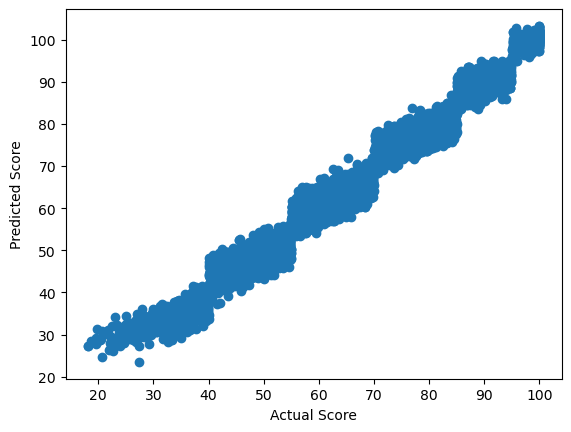

In [33]:
import matplotlib.pyplot as plt

plt.scatter(Y_test,model.predict(X_test))
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [36]:
scaler = StandardScaler()

X = df.drop("overall_score",axis=1)
Y = df["overall_score"]

X = scaler.fit_transform(X)

In [37]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [38]:
lr = LinearRegression()
lr.fit(X_train,Y_train)

LinearRegression()

In [39]:
ridge = Ridge()
ridge.fit(X_train,Y_train)

Ridge()

In [40]:
lasso = Lasso()
lasso.fit(X_train,Y_train)

Lasso()

In [41]:
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

In [42]:
print("Linear Regression R2:",r2_score(Y_test,lr_pred))
print("Ridge Regression R2:",r2_score(Y_test,ridge_pred))
print("Lasso Regression R2:",r2_score(Y_test,lasso_pred))

Linear Regression R2: 0.9748753816571495
Ridge Regression R2: 0.9748753781725761
Lasso Regression R2: 0.9682725030153602


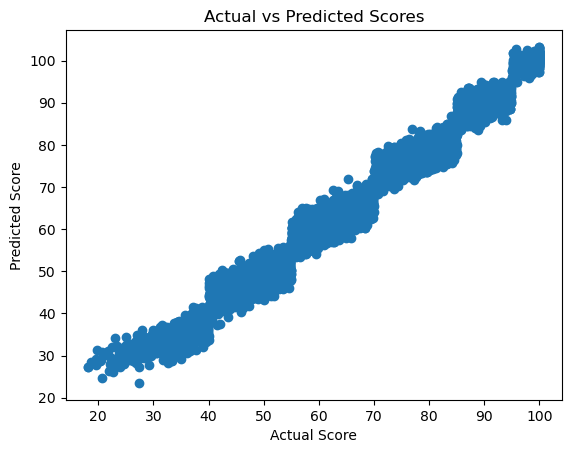

In [43]:
plt.scatter(Y_test,lr_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()

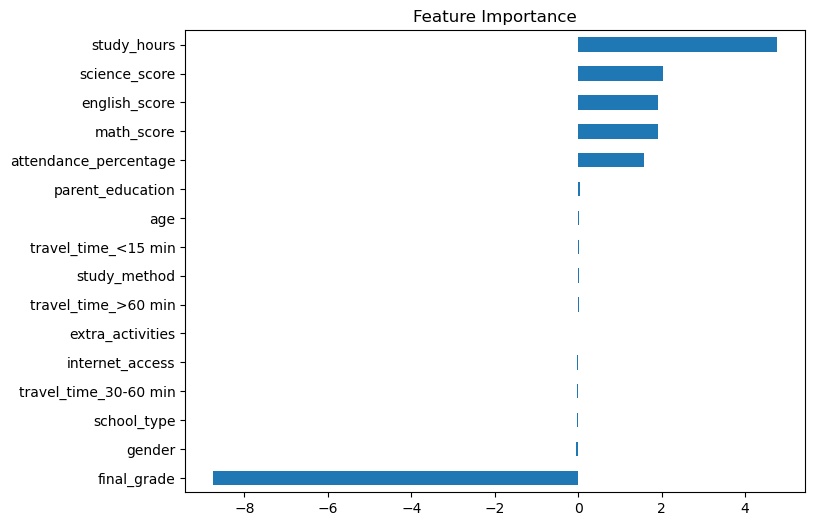

In [44]:
importance = pd.Series(lr.coef_,index=df.drop("overall_score",axis=1).columns)

importance.sort_values().plot(kind="barh",figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [48]:
X = df.drop("final_grade",axis=1)
Y = df["final_grade"]

In [49]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [50]:
model = RandomForestClassifier()

model.fit(X_train,Y_train)

RandomForestClassifier()

In [51]:
Y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(Y_test,Y_pred))

Accuracy: 0.999


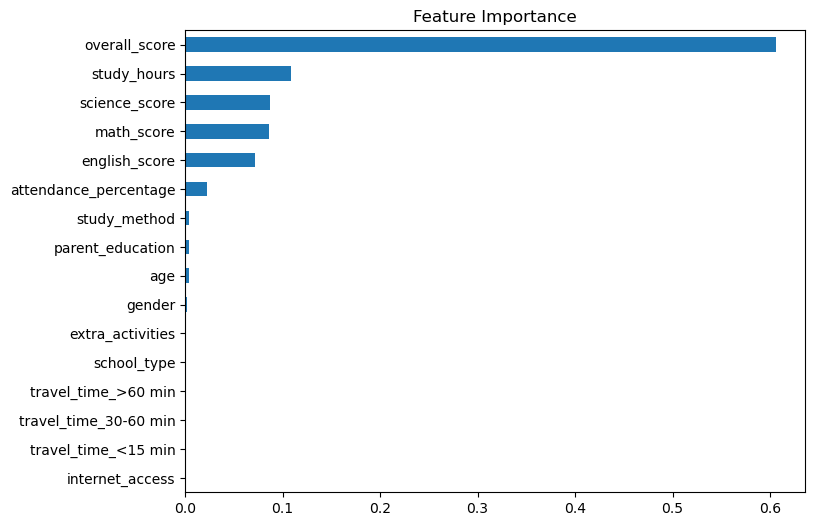

In [52]:
importance = model.feature_importances_

feature_names = X.columns

imp = pd.Series(importance,index=feature_names)

imp.sort_values().plot(kind="barh",figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [54]:
import joblib

joblib.dump(model, "student_model.pkl")

['student_model.pkl']

In [55]:
import os
os.getcwd()

'C:\\Users\\my'

In [56]:
os.listdir()

['.anaconda',
 '.android',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.emulator_console_auth_token',
 '.gitconfig',
 '.gk',
 '.gradle',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.streamlit',
 '.virtual_documents',
 '.vscode',
 '3D Objects',
 'AI resume_checker .ipynb',
 'anaconda3',
 'AndroidStudioProjects',
 'app.c',
 'app.exe',
 'App.py',
 'AppData',
 'Application Data',
 'c language',
 'Car_purchase_prediction_system .ipynb',
 'child1 = {.py',
 'Contacts',
 'Cookies',
 'Customer_Shopping_Behaviour_Analysis.ipynb',
 'Data cleaning and preprocessing .ipynb',
 'Data selection and filtering .ipynb',
 'Desktop',
 'details.csv',
 'Documents',
 'Downloads',
 'Favorites',
 'file.html',
 'harshit.csv',
 'House price pridiction system.ipynb',
 'IntelGraphicsProfiles',
 'Linear regression.ipynb',
 'Links',
 'Local Settings',
 'Melts and pivot.ipynb',
 'model.pkl',
 'Music',
 'My Documents',
 'NetHood',
 'New folder',
 'New folder (2)',
 '

In [57]:
import joblib

joblib.dump(model,"student_model.pkl")

['student_model.pkl']

In [58]:
joblib.dump(model,r"C:\Users\my\Desktop\student_model.pkl")

['C:\\Users\\my\\Desktop\\student_model.pkl']